In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Para gráficos mais “limpos”
plt.rcParams["figure.figsize"] = (6, 5)
plt.rcParams["axes.grid"] = True

# ==============================
# 2. Leitura do Excel
# ==============================
# Ajuste aqui o nome do arquivo e a coluna alvo (y)
ARQUIVO_EXCEL = "/content/data_models.xlsx"      # <- coloque o nome do seu arquivo
NOME_COLUNA_ALVO = "wexp (mm)"                 # <- coloque aqui o nome da coluna resposta

# Lê a planilha (primeira aba por padrão)
df = pd.read_excel(ARQUIVO_EXCEL)
df.drop(['Autor'], axis=1, inplace=True)
df

,Diâmetro da armadura f (mm),Número de barras em uma camada,Espaçamento entre as barras (mm),Resistência à tração do concreto fctm (MPa),Cobrimento c (mm),Distância ao centro de gravidade da armadura d' (mm),Taxa de armadura r,Tensão na armadura (MPa),wexp (mm)
0,20.0,2,126.0,4.120341,25.0,39.0,0.060724,231.811005,0.16
1,20.0,2,126.0,4.120341,25.0,39.0,0.060724,304.251944,0.23
2,20.0,2,126.0,4.120341,25.0,39.0,0.060724,314.282228,0.24
3,20.0,2,126.0,4.120341,25.0,39.0,0.060724,363.319171,0.27
4,20.0,2,126.0,4.120341,25.0,39.0,0.060724,459.164106,0.35
...,...,...,...,...,...,...,...,...,...
337,28.7,2,50.6,2.576579,38.0,52.3,0.065570,248.170924,0.19
338,28.7,2,50.6,2.576579,38.0,52.3,0.065570,275.800000,0.22
339,35.8,2,36.4,2.547836,38.0,55.9,0.112443,184.086481,0.17
340,35.8,2,36.4,2.756373,38.0,55.9,0.111410,143.792877,0.19


Colunas encontradas no dataset:
Index(['Diâmetro da armadura f (mm)', 'Número de barras em uma camada',
       'Espaçamento entre as barras (mm)',
       'Resistência à tração do concreto fctm (MPa)', 'Cobrimento c (mm)',
       'Distância ao centro de gravidade da armadura d' (mm)',
       'Taxa de armadura r', 'Tensão na armadura (MPa)', 'wexp (mm)'],
      dtype='object')

Formato de X: (342, 8)
Formato de y: (342,)

Variância explicada por componente (PCA): [0.3036343  0.25279812]
Variância total explicada (2 PCs): 0.5564324206216055


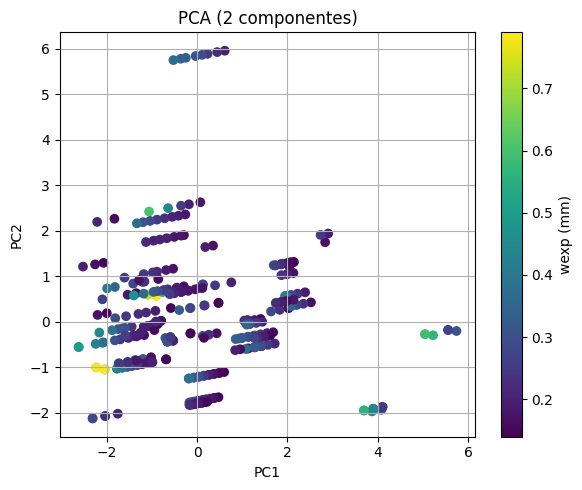

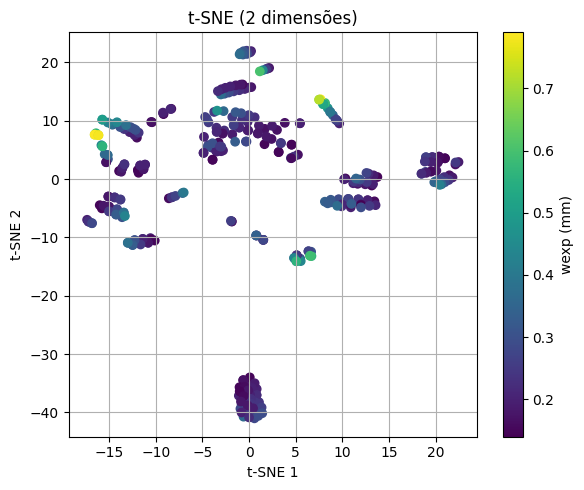


Arquivo 'resultado_pca_tsne.xlsx' gerado com sucesso.


In [ ]:
print("Colunas encontradas no dataset:")
print(df.columns)

# Separa X e y
y = df[NOME_COLUNA_ALVO]
X = df.drop(columns=[NOME_COLUNA_ALVO])

print("\nFormato de X:", X.shape)
print("Formato de y:", y.shape)

# ==============================
# 3. Padronização dos dados (média 0, desvio 1)
# ==============================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==============================
# 4. PCA (redução para 2 componentes)
# ==============================
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("\nVariância explicada por componente (PCA):", pca.explained_variance_ratio_)
print("Variância total explicada (2 PCs):", pca.explained_variance_ratio_.sum())

# Plot PCA em 2D
plt.figure()
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap="viridis")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA (2 componentes)")
cbar = plt.colorbar(scatter)
cbar.set_label(NOME_COLUNA_ALVO)
plt.tight_layout()
plt.show()

# ==============================
# 5. t-SNE (redução para 2 dimensões)
# ==============================
# t-SNE é mais pesado; para datasets muito grandes, pode demorar.
tsne = TSNE(
    n_components=2,
    perplexity=30,      # ajuste fino se necessário
    learning_rate="auto",
    init="pca",
    random_state=42
)

X_tsne = tsne.fit_transform(X_scaled)

# Plot t-SNE em 2D
plt.figure()
scatter_tsne = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap="viridis")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE (2 dimensões)")
cbar_tsne = plt.colorbar(scatter_tsne)
cbar_tsne.set_label(NOME_COLUNA_ALVO)
plt.tight_layout()
plt.show()

# ==============================
# 6. Salvar resultados em Excel (opcional)
# ==============================
# Adiciona as colunas de PCA e t-SNE ao DataFrame original
df["PCA1"] = X_pca[:, 0]
df["PCA2"] = X_pca[:, 1]
df["TSNE1"] = X_tsne[:, 0]
df["TSNE2"] = X_tsne[:, 1]

df.to_excel("resultado_pca_tsne.xlsx", index=False)
print("\nArquivo 'resultado_pca_tsne.xlsx' gerado com sucesso.")
